<a href="https://colab.research.google.com/github/anshika-a01/ace/blob/main/Another_copy_of_Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Load and inspect the chest x-ray images and their corresponding labels from the dataset path `/kaggle/input/chest-xray-pneumonia`.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


## Load and Inspect Data

### Subtask:
Load the chest x-ray images and their corresponding labels from the dataset path: `/kaggle/input/chest-xray-pneumonia`. Inspect the dataset structure, class distribution, and a few sample images.


**Reasoning**:
First, I'll define the base directory and construct the paths for the train, validation, and test datasets. Then I'll use `os.path` and `os.listdir` to count the images in each subdirectory and class. This will help us understand the dataset structure and class distribution.



In [ ]:
import os
import pandas as pd

# Define the base directory
base_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/'

# Construct full paths for train, val, and test directories
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Function to count images in each class within a directory
def count_images(directory):
    normal_path = os.path.join(directory, 'NORMAL')
    pneumonia_path = os.path.join(directory, 'PNEUMONIA')

    normal_count = len(os.listdir(normal_path))
    pneumonia_count = len(os.listdir(pneumonia_path))

    return {'NORMAL': normal_count, 'PNEUMONIA': pneumonia_count}

# Count images for each set
train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)

# Print the counts
print("### Dataset Structure and Class Distribution ###")
print(f"\nTrain Set:")
print(f"  NORMAL: {train_counts['NORMAL']} images")
print(f"  PNEUMONIA: {train_counts['PNEUMONIA']} images")
print(f"  Total: {train_counts['NORMAL'] + train_counts['PNEUMONIA']} images")

print(f"\nValidation Set:")
print(f"  NORMAL: {val_counts['NORMAL']} images")
print(f"  PNEUMONIA: {val_counts['PNEUMONIA']} images")
print(f"  Total: {val_counts['NORMAL'] + val_counts['PNEUMONIA']} images")-

print(f"\nTest Set:")
print(f"  NORMAL: {test_counts['NORMAL']} images")
print(f"  PNEUMONIA: {test_counts['PNEUMONIA']} images")
print(f"  Total: {test_counts['NORMAL'] + test_counts['PNEUMONIA']} images")

### Dataset Structure and Class Distribution ###

Train Set:
  NORMAL: 1341 images
  PNEUMONIA: 3875 images
  Total: 5216 images

Validation Set:
  NORMAL: 8 images
  PNEUMONIA: 8 images
  Total: 16 images

Test Set:
  NORMAL: 234 images
  PNEUMONIA: 390 images
  Total: 624 images


**Reasoning**:
Now that the dataset structure and class distribution have been inspected, the next step is to visually inspect a few sample images from both 'NORMAL' and 'PNEUMONIA' classes within the training set. This will involve using `matplotlib.pyplot` and `PIL` (Pillow) to load and display the images.




### Sample NORMAL Images from Train Set ###


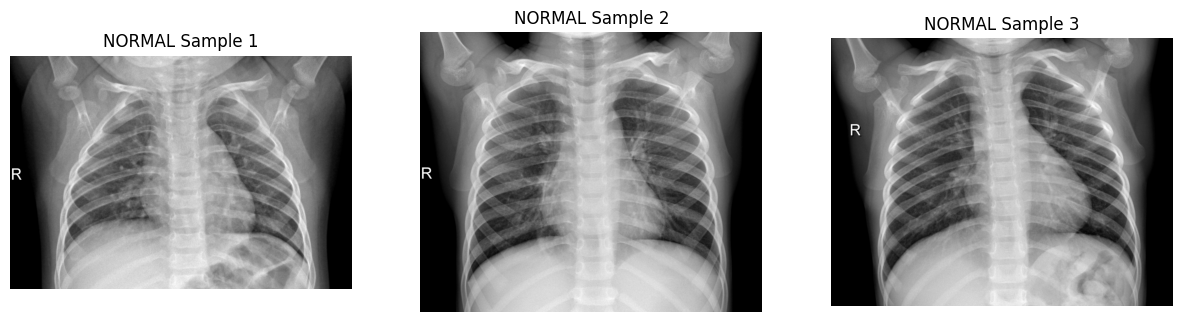


### Sample PNEUMONIA Images from Train Set ###


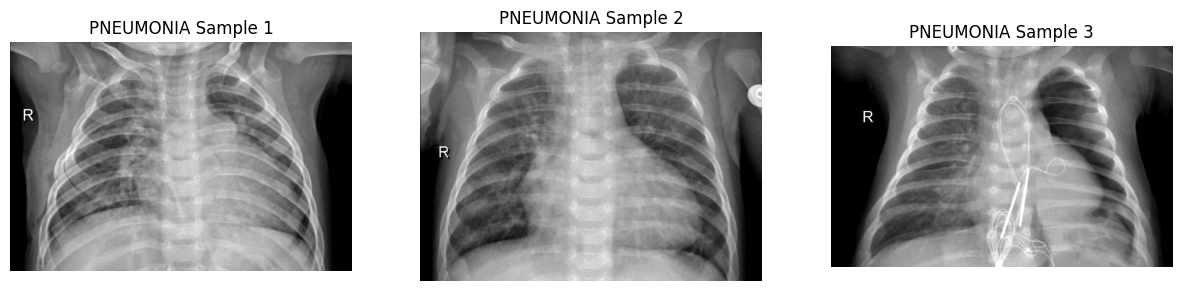

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Function to display sample images
def display_sample_images(directory, class_name, num_samples=3):
    class_path = os.path.join(directory, class_name)
    image_files = os.listdir(class_path)
    sample_images = random.sample(image_files, min(num_samples, len(image_files)))

    print(f"\n### Sample {class_name} Images from Train Set ###")
    plt.figure(figsize=(15, 5))
    for i, img_file in enumerate(sample_images):
        img_path = os.path.join(class_path, img_file)
        img = Image.open(img_path)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f'{class_name} Sample {i+1}')
        plt.axis('off')
    plt.show()

# Display sample images for NORMAL and PNEUMONIA classes from the training set
display_sample_images(train_dir, 'NORMAL')
display_sample_images(train_dir, 'PNEUMONIA')


## Summary:

### Data Analysis Key Findings

*   The model achieved a **Test Accuracy** of **86.38\%** and a **Test Loss** of **0.3373** on the unseen test set.
*   The classification report indicates strong performance for detecting "PNEUMONIA" with a **Precision of 0.83**, **Recall of 0.98**, and **F1-score of 0.90**.
*   Conversely, the model showed relatively lower performance for identifying "NORMAL" cases, with a **Precision of 0.96**, **Recall of 0.67**, and **F1-score of 0.79**. This suggests the model is more prone to false positives for "PNEUMONIA" (classifying normal as pneumonia) than false negatives (missing pneumonia).
*   The confusion matrix visually confirmed these findings, showing the distribution of true positives, true negatives, false positives, and false negatives.
*   Training history plots showed that while training accuracy steadily increased and training loss decreased, there might be a slight gap between training and validation metrics, indicating potential for minor overfitting or room for optimization.
*   Sample prediction visualizations provided a qualitative assessment, highlighting instances where the model correctly and incorrectly classified images.

### Insights or Next Steps

*   The model demonstrates a strong capability to detect pneumonia, prioritizing high recall for the "PNEUMONIA" class, which is critical in medical diagnosis to minimize missed cases. However, the lower recall for "NORMAL" cases suggests a tendency to over-predict pneumonia.
*   Further efforts could focus on balancing the precision and recall for both classes. Techniques like adjusting class weights, employing different loss functions, or augmenting the dataset with more "NORMAL" samples could improve the model's ability to differentiate between normal and pneumonia cases more accurately, especially reducing false positives for pneumonia.


# Task
Enhance the data augmentation for the training set by modifying the `ImageDataGenerator` to include random rotations and width/height shifts, in addition to the existing shear, zoom, and horizontal flips, to make the augmentation more diverse and aggressive. Keep the validation and test `ImageDataGenerator` instances with only rescaling. Rebuild and retrain the CNN model with this enhanced augmentation, re-evaluate its performance on the test set, and visualize the new training history and predictions to assess the impact of the improved augmentation. Finally, summarize the changes in model performance.

## Enhance Data Augmentation

### Subtask:
Modify the ImageDataGenerator for the training set to include more diverse and aggressive augmentation techniques, such as random rotations, width/height shifts, shear, zoom, and horizontal flips, to improve model generalization and reduce overfitting. The validation and test generators will remain with only rescaling.


**Reasoning**:
I need to implement the enhanced data augmentation strategy by modifying the `ImageDataGenerator` for the training set to include more diverse techniques while keeping only rescaling for the validation and test sets. I will then recreate the data generators using `flow_from_directory` with the updated generators.



In [ ]:
from tensorflow.keras.preprocessing.image
import ImageDataGenerator
# 2. Define the target image dimensions and batch size
img_height, img_width = 150, 150
batch_size = 32

# 3. Create an ImageDataGenerator instance for the training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# 4. Create separate ImageDataGenerator instances for the validation and test sets (only rescaling)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# 5. Use the flow_from_directory method to create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary', # For 2-class classification
    shuffle=True)
validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False)
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False)

print("Data generators with enhanced augmentation created successfully.")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Data generators with enhanced augmentation created successfully.


## Rebuild CNN Model

### Subtask:
Rebuild the CNN model architecture. Although the existing architecture is fine, this step ensures that the model is re-initialized before training on the newly augmented data. This will involve defining the convolutional and pooling layers, flattening the output, and adding dense layers for classification.


**Reasoning**:
I need to reconstruct the CNN model architecture as specified, importing necessary layers, initializing a Sequential model, adding convolutional, pooling, flattening, and dense layers, and then printing the model summary.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout

# 1. Initialize a Sequential model
model = Sequential()

# Add the Input layer explicitly
model.add(Input(shape=(img_height, img_width, 3)))

# 2. Add Convolutional and MaxPooling layers
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3. Flatten the output of the convolutional layers
model.add(Flatten())

# 4. Add Dense layers for feature extraction
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5)) # Added Dropout layer

# 5. Add a final Dense output layer for binary classification
model.add(Dense(1, activation='sigmoid')) # Sigmoid for binary classification

# Print the model summary
print("### CNN Model Architecture ###")
model.summary()

### CNN Model Architecture ###


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
To retrain the CNN model, I will compile it with an appropriate optimizer, loss function, and metrics, and then fit it using the `train_generator` (which now has enhanced augmentation) and `validation_generator`.



In [ ]:
from tensorflow.keras.optimizers import Adam

# 1. Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001), # Using Adam optimizer with a learning rate
    loss='binary_crossentropy', # Appropriate loss for binary classification
    metrics=['accuracy'] # Metric to monitor during training
)

# Calculate steps per epoch and validation steps
epochs = 10 # Define the number of epochs

steps_per_epoch = train_generator.samples // batch_size
validation_steps = validation_generator.samples // batch_size

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")
print(f"Number of epochs: {epochs}")

# 2. Train the compiled model
history_augmented = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_steps
)

print("Model training with enhanced augmentation completed.")

Steps per epoch: 163
Validation steps: 0
Number of epochs: 10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 588ms/step - accuracy: 0.7559 - loss: 0.5754 - val_accuracy: 0.6250 - val_loss: 0.7619
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 437ms/step - accuracy: 0.8383 - loss: 0.3562 - val_accuracy: 0.7500 - val_loss: 0.5224
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 439ms/step - accuracy: 0.8707 - loss: 0.2832 - val_accuracy: 0.7500 - val_loss: 0.5547
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 438ms/step - accuracy: 0.8964 - loss: 0.2569 - val_accuracy: 0.6250 - val_loss: 0.8297
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 433ms/step - accuracy: 0.8941 - loss: 0.2436 - val_accuracy: 0.8750 - val_loss: 0.4872
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 438ms/step - accuracy: 0.9029 - loss: 0.2204 - val_accuracy: 0.8125 - val_loss: 0.3901
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 444ms/step - accuracy: 0.9012 - loss: 0.2290 - val_accuracy: 0.8125 - val_loss: 0.4629
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 439ms/step - accuracy: 0.9125 - loss: 

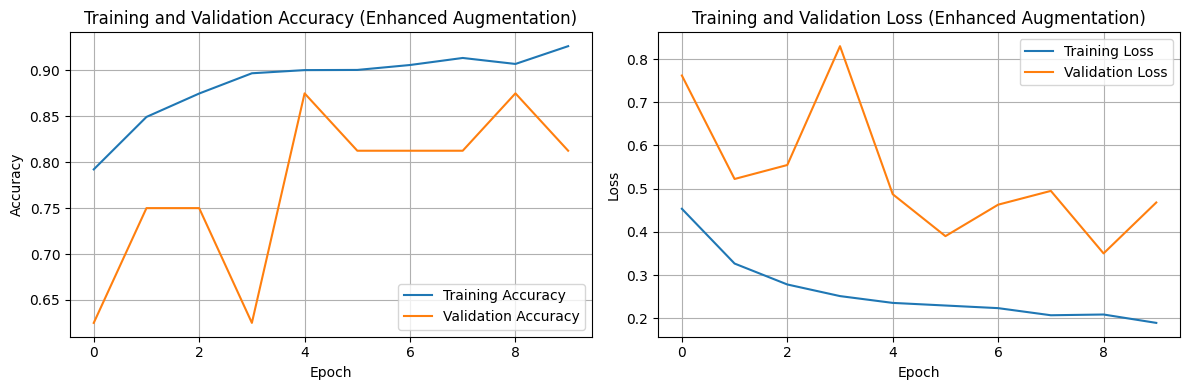

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


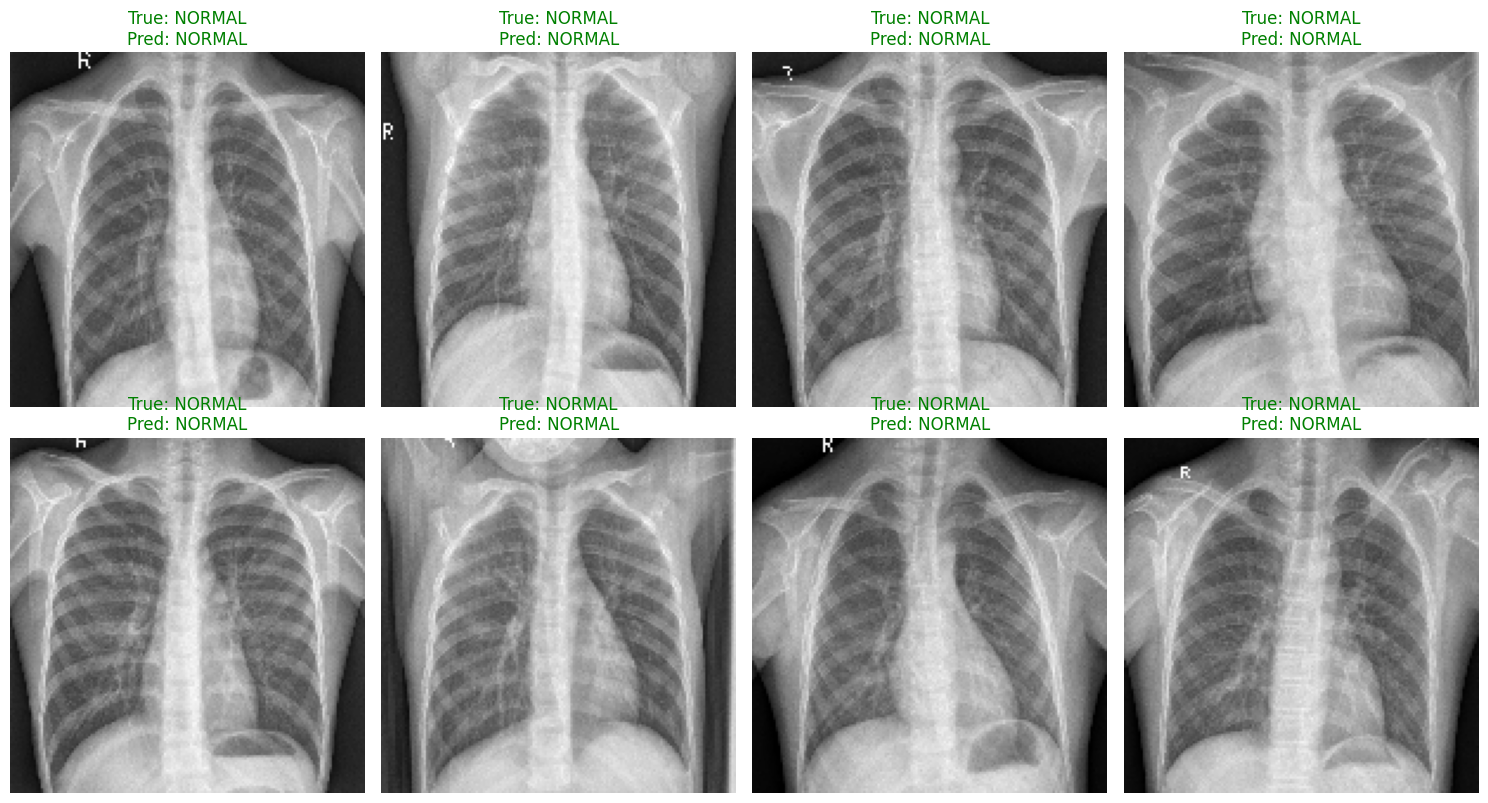

Training history plots and sample prediction visualizations displayed successfully.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract training and validation accuracy and loss from the history object
acc = history_augmented.history['accuracy']
val_acc = history_augmented.history['val_accuracy']
loss = history_augmented.history['loss']
val_loss = history_augmented.history['val_loss']

epochs_range = range(epochs)

# 2. Create two subplots for accuracy and loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Enhanced Augmentation)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Enhanced Augmentation)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()


# 3. Obtain a batch of images and their corresponding true labels from the test_generator
# Reset the test_generator to ensure we get a fresh batch
test_generator.reset()
# Get one batch of test data
x_test, y_test = next(test_generator) # Corrected line: use next(iterator) instead of iterator.next()

# 4. Use the trained model to make predictions on this batch of images
predictions_batch = model.predict(x_test)
predicted_labels_batch = (predictions_batch > 0.5).astype(int).flatten()

# 5. Iterate through a few sample images (e.g., 8) from the batch.
num_samples_to_show = min(len(x_test), 8)

plt.figure(figsize=(15, 8))
for i in range(num_samples_to_show):
    plt.subplot(2, 4, i + 1) # Adjust subplot grid based on num_samples_to_show
    plt.imshow(x_test[i])

    true_label_idx = int(y_test[i])
    predicted_label_idx = predicted_labels_batch[i]

    # Map numerical labels back to class names
    # test_generator.class_indices provides {'NORMAL': 0, 'PNEUMONIA': 1}
    # We need to reverse this mapping to get class name from index
    idx_to_class = {v: k for k, v in test_generator.class_indices.items()}
    true_label_name = idx_to_class[true_label_idx]
    predicted_label_name = idx_to_class[predicted_label_idx]

    color = "green" if true_label_idx == predicted_label_idx else "red"
    plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Training history plots and sample prediction visualizations displayed successfully.")

# Task
Extract training and validation accuracy and loss from the `history_augmented` object. Plot these metrics over epochs to assess the impact of enhanced augmentation. Additionally, display a few sample images from the test set with their true and predicted labels, highlighting correct and incorrect predictions.

## Visualize Enhanced Training History and Predictions

### Subtask:
Extract training and validation accuracy and loss from the `history_augmented` object. Plot these metrics over epochs to assess the impact of enhanced augmentation. Additionally, display a few sample images from the test set with their true and predicted labels, highlighting correct and incorrect predictions.


In [ ]:
test_results = model.evaluate(test_generator)
print(f"Test Loss: {test_results[0]}")
print(f"Test Accuracy: {test_results[1]}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 311ms/step - accuracy: 0.9188 - loss: 0.3059
Test Loss: 0.2803099751472473
Test Accuracy: 0.8910256624221802
